In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
matches = pd.read_csv('data/matches.csv')
deliveries = pd.read_csv('data/deliveries.csv')

print("Matches dataset shape:", matches.shape)
print("Deliveries dataset shape:", deliveries.shape)

Matches dataset shape: (1095, 20)
Deliveries dataset shape: (260920, 17)


In [6]:
import os
print(os.getcwd())

C:\Users\User


In [7]:
import os
os.chdir(r'C:\Users\User\Desktop')
print("Location changed successfully!")

Location changed successfully!


In [9]:
# First 5 rows of matches
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [10]:
# Check missing values
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [11]:
# Check duplicates
print("Duplicate rows:", matches.duplicated().sum())

Duplicate rows: 0


In [12]:
# Fill missing city with Unknown
matches['city'].fillna('Unknown', inplace=True)

# Drop rows where winner is missing (abandoned matches)
matches.dropna(subset=['winner'], inplace=True)

# Fill method column with Normal
matches['method'].fillna('Normal', inplace=True)

print("Data cleaned successfully!")
print("Remaining rows:", matches.shape[0])

Data cleaned successfully!
Remaining rows: 1090


C:\Users\User\AppData\Local\Temp\ipykernel_15616\1403061673.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['city'].fillna('Unknown', inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_15616\1403061673.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [13]:
# Clean data the proper way
matches = matches.fillna({'city': 'Unknown', 'method': 'Normal'})

# Drop rows where winner is missing (abandoned matches)
matches = matches.dropna(subset=['winner'])

print("Data cleaned successfully!")
print("Remaining rows:", matches.shape[0])

Data cleaned successfully!
Remaining rows: 1090


C:\Users\User\AppData\Local\Temp\ipykernel_15616\3046581190.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wins.values, y=wins.index, palette='viridis')


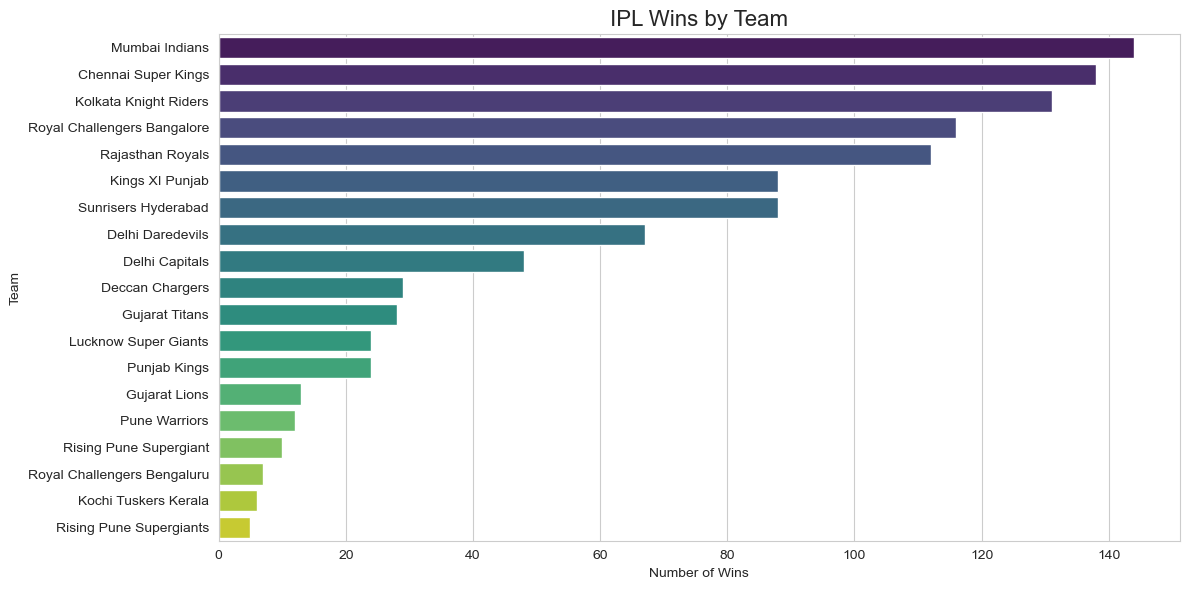

In [14]:
# Count wins per team
wins = matches['winner'].value_counts()

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=wins.values, y=wins.index, palette='viridis')
plt.title('IPL Wins by Team', fontsize=16)
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

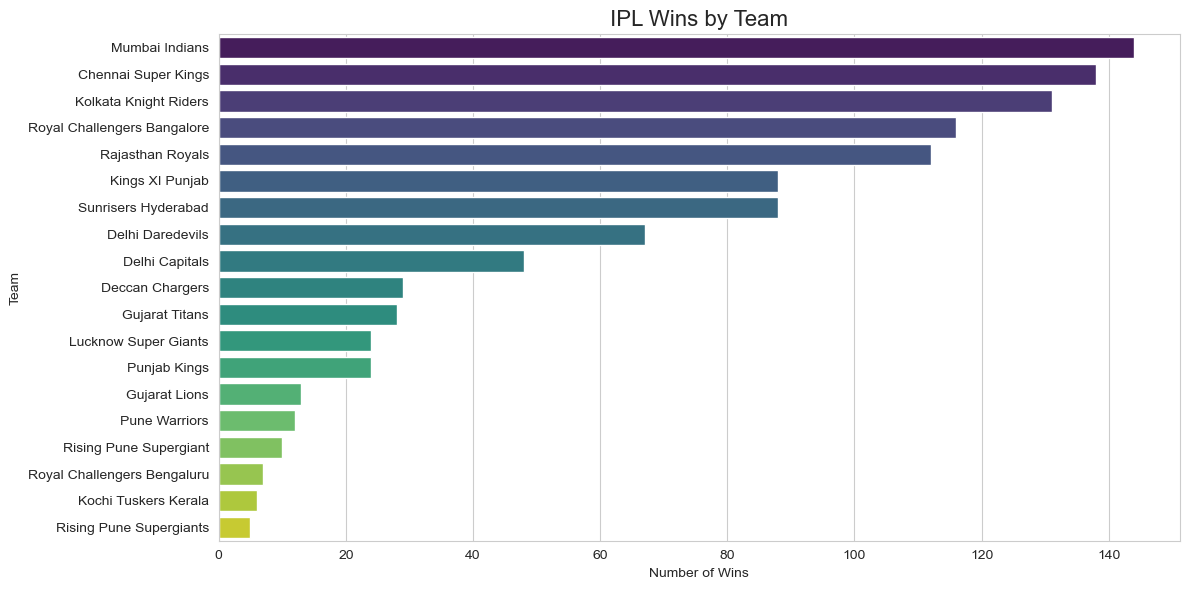

In [15]:
# Count wins per team
wins = matches['winner'].value_counts()

# Plot (updated code)
plt.figure(figsize=(12,6))
sns.barplot(x=wins.values, y=wins.index, hue=wins.index, palette='viridis', legend=False)
plt.title('IPL Wins by Team', fontsize=16)
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

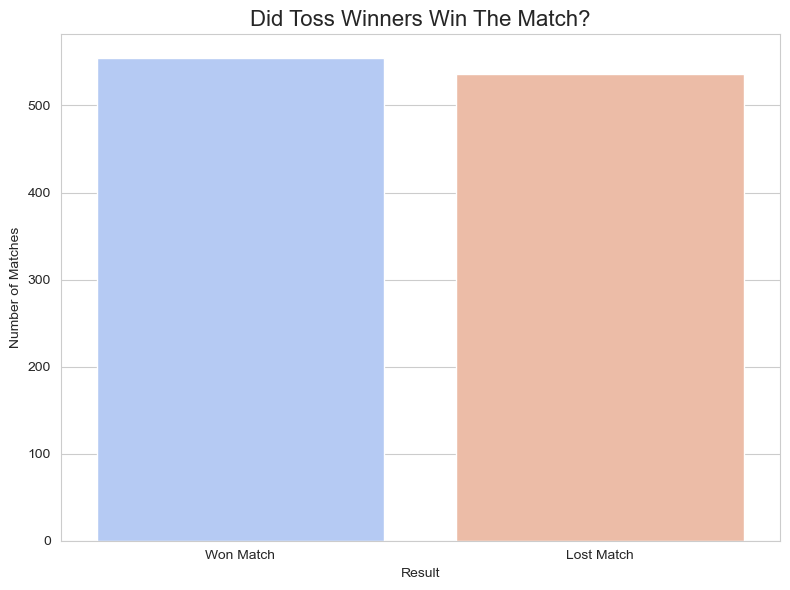

Toss winners won the match 50.83% of the time


In [16]:
# Check if toss winner is also match winner
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']

# Count
toss_win = matches['toss_match_winner'].value_counts()

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x=['Won Match', 'Lost Match'], y=toss_win.values, 
            hue=['Won Match', 'Lost Match'], palette='coolwarm', legend=False)
plt.title('Did Toss Winners Win The Match?', fontsize=16)
plt.xlabel('Result')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()

# Print percentage
percentage = round(toss_win[True] / toss_win.sum() * 100, 2)
print(f"Toss winners won the match {percentage}% of the time")

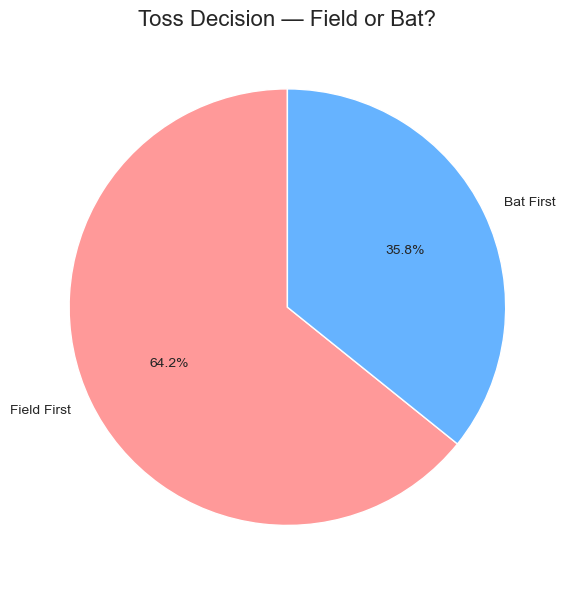

toss_decision
field    700
bat      390
Name: count, dtype: int64


In [17]:
# Toss decision breakdown
toss_decision = matches['toss_decision'].value_counts()

# Plot
plt.figure(figsize=(8,6))
plt.pie(toss_decision.values, 
        labels=['Field First', 'Bat First'], 
        autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff'],
        startangle=90)
plt.title('Toss Decision — Field or Bat?', fontsize=16)
plt.tight_layout()
plt.show()

print(toss_decision)

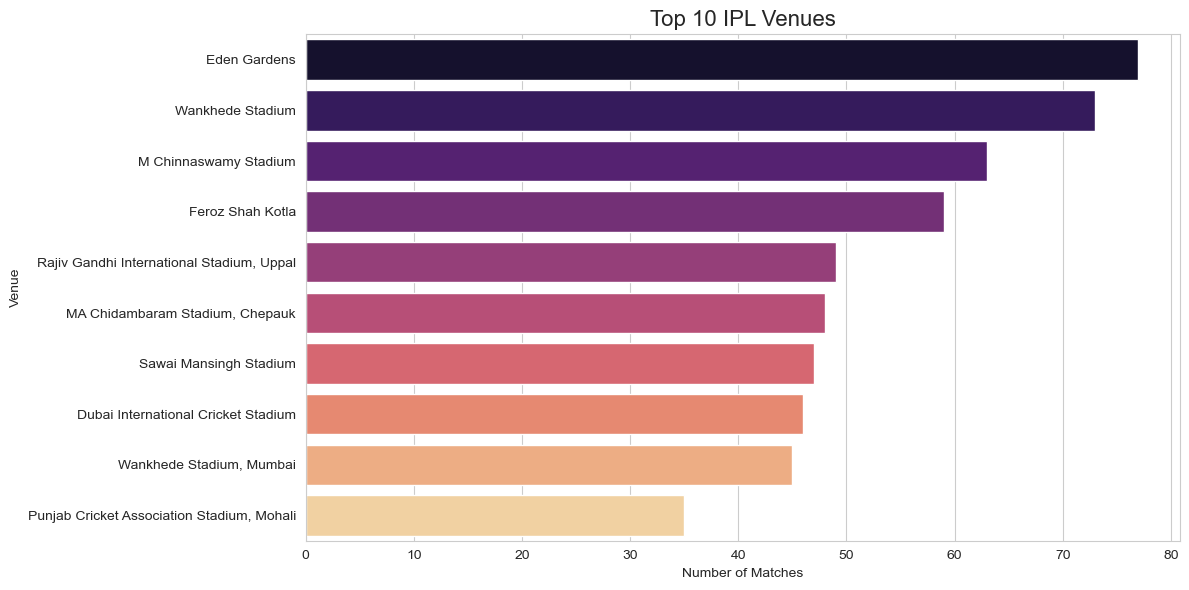

In [18]:
# Top 10 venues
venues = matches['venue'].value_counts().head(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=venues.values, y=venues.index, 
            hue=venues.index, palette='magma', legend=False)
plt.title('Top 10 IPL Venues', fontsize=16)
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

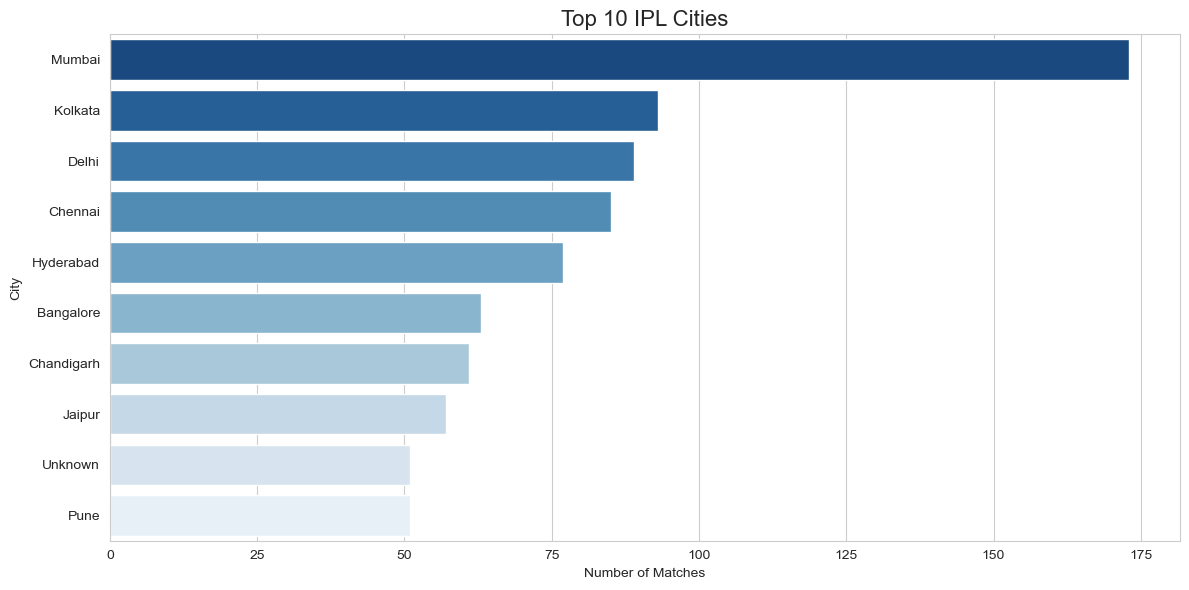

In [19]:
# Top 10 cities
cities = matches['city'].value_counts().head(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=cities.values, y=cities.index,
            hue=cities.index, palette='Blues_r', legend=False)
plt.title('Top 10 IPL Cities', fontsize=16)
plt.xlabel('Number of Matches')
plt.ylabel('City')
plt.tight_layout()
plt.show()

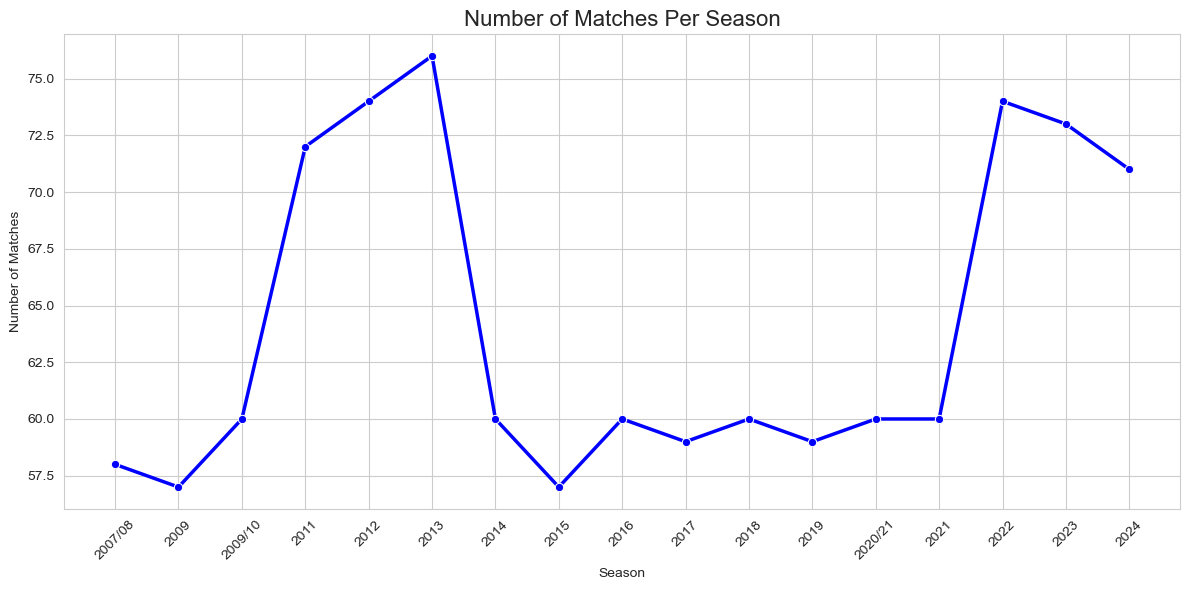

In [20]:
# Matches per season
season_matches = matches['season'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(x=season_matches.index, y=season_matches.values, 
             marker='o', color='blue', linewidth=2.5)
plt.title('Number of Matches Per Season', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 📊 IPL EDA — Key Findings & Conclusions

## 🏆 Summary of Insights

1. **Mumbai Indians** have won the most IPL matches — 
   they are the most dominant team in IPL history.

2. **Winning the toss gives almost no advantage** — 
   toss winners only win 50.83% of the time.

3. **Teams prefer fielding first** — 64% of toss winners 
   choose to field, showing chasing is the preferred strategy.

4. **Eden Gardens** is the most iconic IPL venue — 
   hosting the most matches in IPL history.

5. **Mumbai** is the IPL capital of India — 
   hosting the most matches of any city.

6. **2013** was the biggest IPL season — 
   with the most matches ever played.

## 🔍 Further Analysis Possible
- Top run scorers and wicket takers
- Player of the match analysis
- Win percentage by batting first vs chasing